# IPL Jersey Identification - EDA + Feature Engineering

This notebook covers:

1. Imports and Configuration
2. Dataset Loading
3. Dataset Validation
4. EDA (Task 3.1)
5. EDA (Task 3.2)
6. Feature Engineering
7. Training Dataset Creation
8. Feature CSV Export

Each row in the final feature dataset represents **one grid cell** from an image.


In [2]:
# =====================================
# Imports
# =====================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

import cv2

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

from tqdm import tqdm

from skimage.feature import (
    local_binary_pattern,
    hog,
    graycomatrix,
    graycoprops
)

from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

plt.style.use("default")
%matplotlib inline


In [3]:
# =====================================
# Configuration
# =====================================

PROJECT_ROOT = Path(".")

DATA_DIR = PROJECT_ROOT / "../data"
IMAGE_DIR = DATA_DIR / "images"

LABEL_CSV = DATA_DIR / "master.csv"

TEAM_MAP = {
    0:'No Team',
    1:'CSK',
    2:'DC',
    3:'GT',
    4:'KKR',
    5:'LSG',
    6:'MI',
    7:'PBKS',
    8:'RR',
    9:'RCB',
    10:'SRH'
}

RANDOM_STATE = 42


In [4]:
# =====================================
# Helper Functions
# =====================================

def load_image(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    return image


def get_cell_columns(df):

    return sorted(
        [c for c in df.columns if c.startswith("c")]
    )


In [5]:
# =====================================
# Load Dataset
# =====================================

df = pd.read_csv(LABEL_CSV)

print("Dataset Shape:", df.shape)

display(df.head())


Dataset Shape: (3073, 68)


,image,labelled_by,num_players,submitted_by,c01,c02,c03,c04,c05,c06,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,c64
0,GTvsLSG_image_0.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,GTvsLSG_image_1.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GTvsLSG_image_10.jpg,Vishal,2.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GTvsLSG_image_11.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GTvsLSG_image_12.jpg,Vishal,1.0,Group1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,5,0,0


## Dataset Validation

In [6]:
print(df.info())

print("\nMissing Values")
display(df.isnull().sum())

cell_columns = get_cell_columns(df)

print("\nGrid Cell Columns:", len(cell_columns))


<class 'pandas.DataFrame'>
RangeIndex: 3073 entries, 0 to 3072
Data columns (total 68 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image         3073 non-null   str    
 1   labelled_by   3001 non-null   str    
 2   num_players   1523 non-null   float64
 3   submitted_by  3073 non-null   str    
 4   c01           3073 non-null   int64  
 5   c02           3073 non-null   int64  
 6   c03           3073 non-null   int64  
 7   c04           3073 non-null   int64  
 8   c05           3073 non-null   int64  
 9   c06           3073 non-null   int64  
 10  c07           3073 non-null   int64  
 11  c08           3073 non-null   int64  
 12  c09           3073 non-null   int64  
 13  c10           3073 non-null   int64  
 14  c11           3073 non-null   int64  
 15  c12           3073 non-null   int64  
 16  c13           3073 non-null   int64  
 17  c14           3073 non-null   int64  
 18  c15           3073 non-null   int64  
 

image              0
labelled_by       72
num_players     1550
submitted_by       0
c01                0
                ... 
c60                0
c61                0
c62                0
c63                0
c64                0
Length: 68, dtype: int64


Grid Cell Columns: 64


## Task 3.1 - Class Distribution

In [7]:
# Overall Distribution Including No-Team

all_labels = df[cell_columns].values.flatten()

distribution = (
    pd.Series(all_labels)
      .value_counts()
      .sort_index()
)

distribution_df = pd.DataFrame({
    "Label": distribution.index,
    "Count": distribution.values
})

distribution_df["Team"] = (
    distribution_df["Label"]
    .map(TEAM_MAP)
)

display(distribution_df)


,Label,Count,Team
0,0,162905,No Team
1,1,2814,CSK
2,2,1630,DC
3,3,2484,GT
4,4,4277,KKR
5,5,1435,LSG
6,6,5048,MI
7,7,3558,PBKS
8,8,2610,RR
9,9,3085,RCB


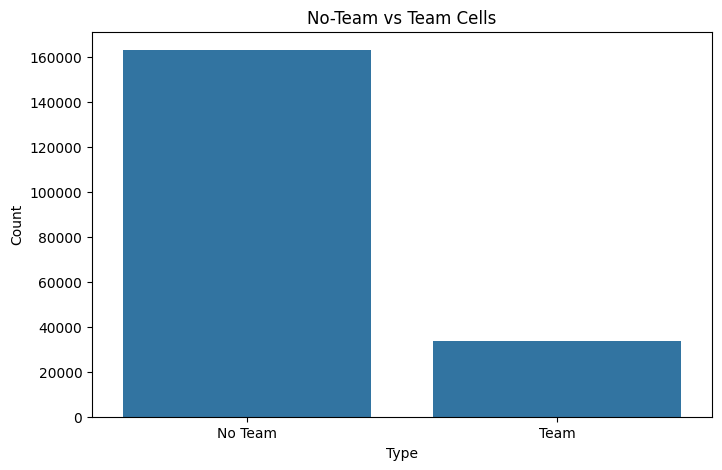

In [8]:
# No-Team vs Team Cells

plt.figure(figsize=(8,5))

summary_df = pd.DataFrame({
    "Type":[
        "No Team",
        "Team"
    ],
    "Count":[
        distribution_df[distribution_df.Label==0].Count.sum(),
        distribution_df[distribution_df.Label!=0].Count.sum()
    ]
})

sns.barplot(
    data=summary_df,
    x="Type",
    y="Count"
)

plt.title("No-Team vs Team Cells")
plt.show()


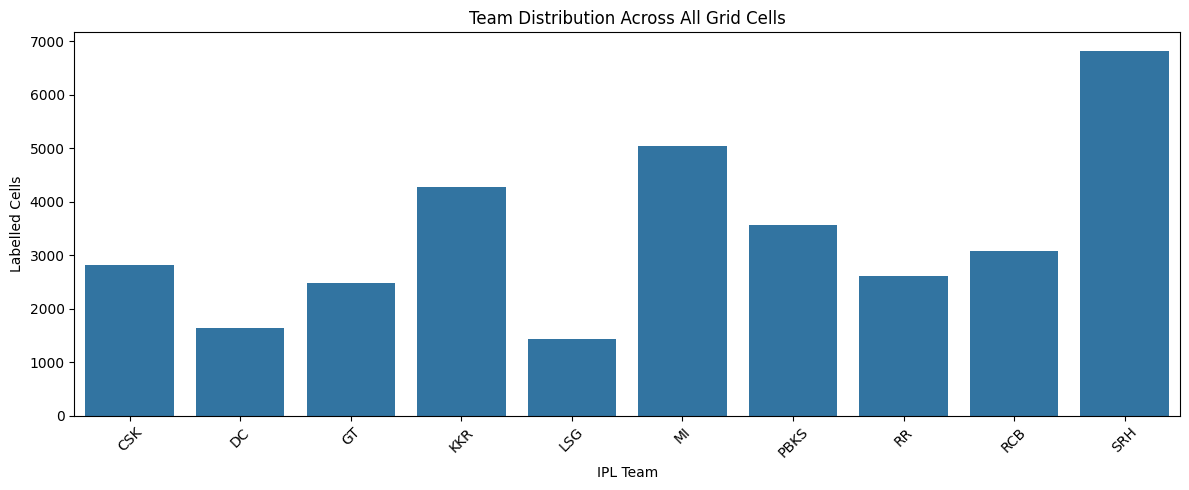

In [9]:
# Team Distribution Only

team_distribution = (
    distribution_df[distribution_df.Label != 0]
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=team_distribution,
    x="Team",
    y="Count"
)

plt.title("Team Distribution Across All Grid Cells")

plt.xlabel("IPL Team")
plt.ylabel("Labelled Cells")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [10]:
# Distribution Percentage

distribution_df["Percentage"] = (
    distribution_df["Count"]
    / distribution_df["Count"].sum()
) * 100

display(
    distribution_df.sort_values(
        "Percentage",
        ascending=False
    )
)


,Label,Count,Team,Percentage
0,0,162905,No Team,82.830805
10,10,6826,SRH,3.470753
6,6,5048,MI,2.566710
4,4,4277,KKR,2.174687
7,7,3558,PBKS,1.809103
9,9,3085,RCB,1.568602
1,1,2814,CSK,1.430809
8,8,2610,RR,1.327083
3,3,2484,GT,1.263017
2,2,1630,DC,0.828791


## Task 3.2 - Feature Visualization

In [11]:
SUPPORTED_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png"
]

image_paths = []

for ext in SUPPORTED_EXTENSIONS:
    image_paths.extend(
        IMAGE_DIR.rglob(f"*{ext}")
    )

image_paths = sorted(image_paths)

print("Images Found:", len(image_paths))


Images Found: 1699


In [12]:
N_SAMPLES = 10

sample_paths = np.random.choice(
    image_paths,
    min(len(image_paths), N_SAMPLES),
    replace=False
)

sample_paths[:5]


array([PosixPath('../data/images/RRvsCSK_image_257.jpg'),
       PosixPath('../data/images/PBKSvsDC_image_70.jpg'),
       PosixPath('../data/images/GTvsMI_image_221.jpg'),
       PosixPath('../data/images/PBKSvsCSK_image_155.jpg'),
       PosixPath('../data/images/RCBvsPBKS_image_89.jpg')], dtype=object)

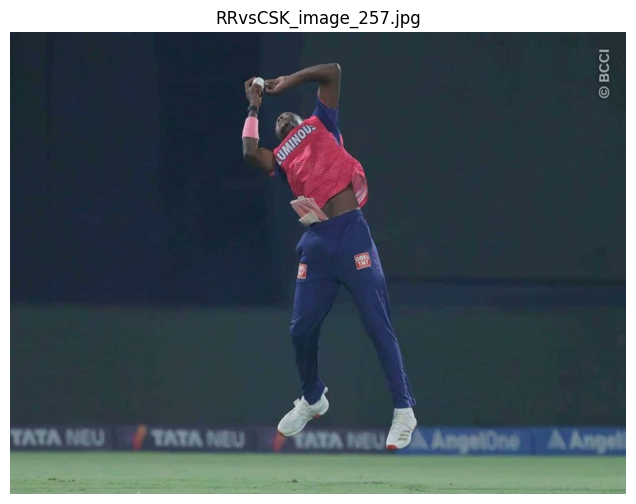

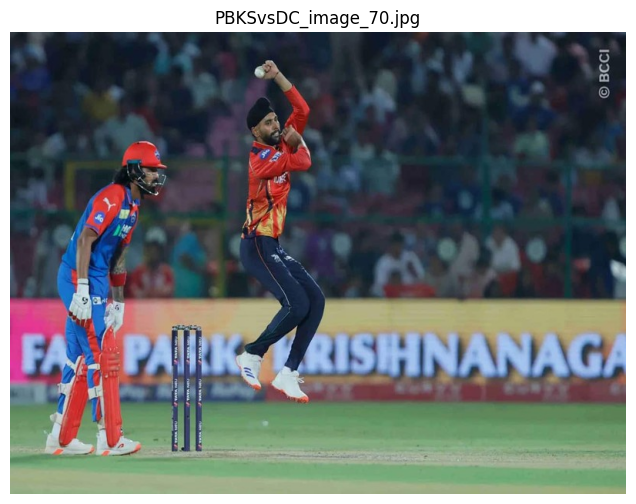

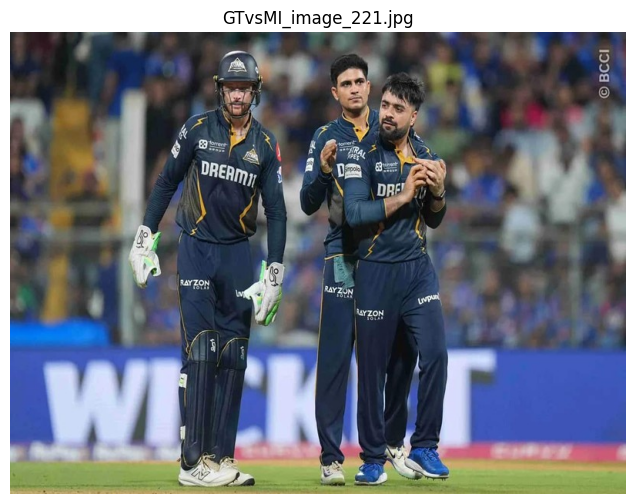

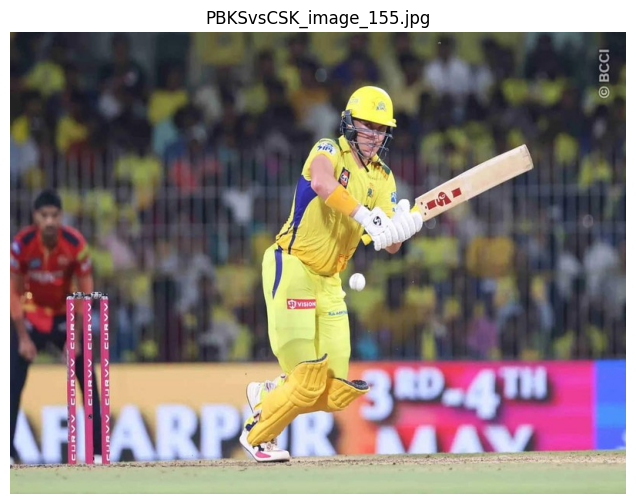

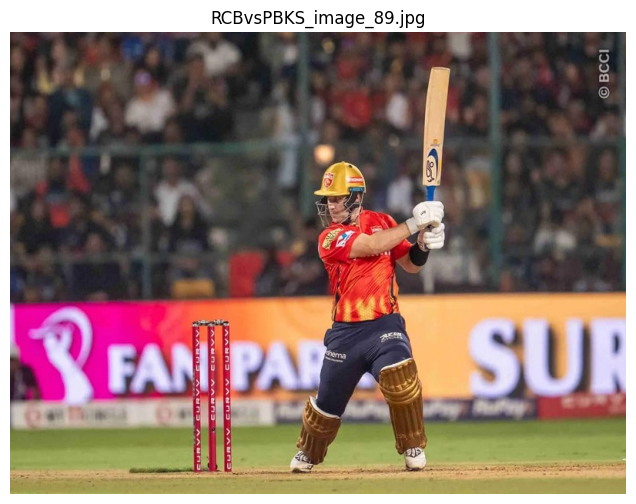

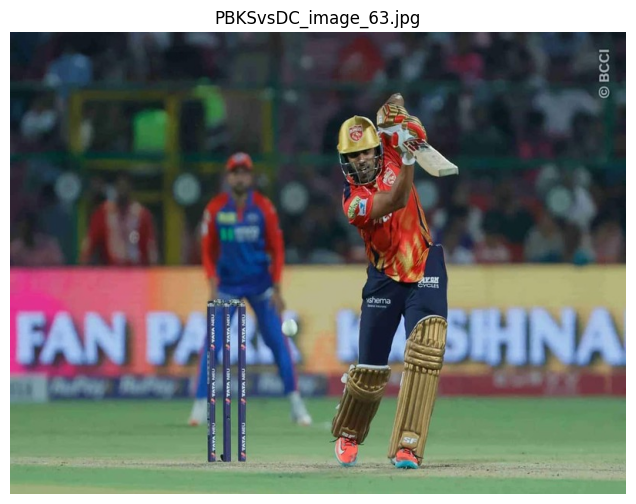

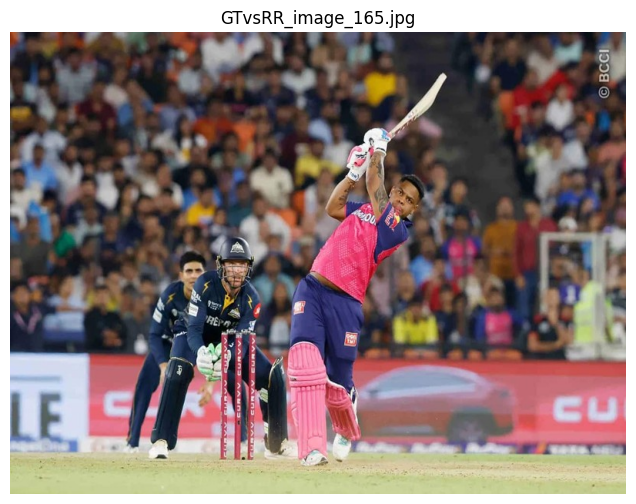

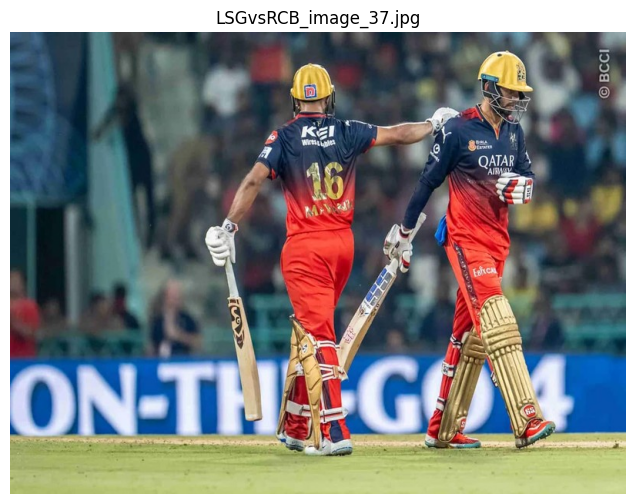

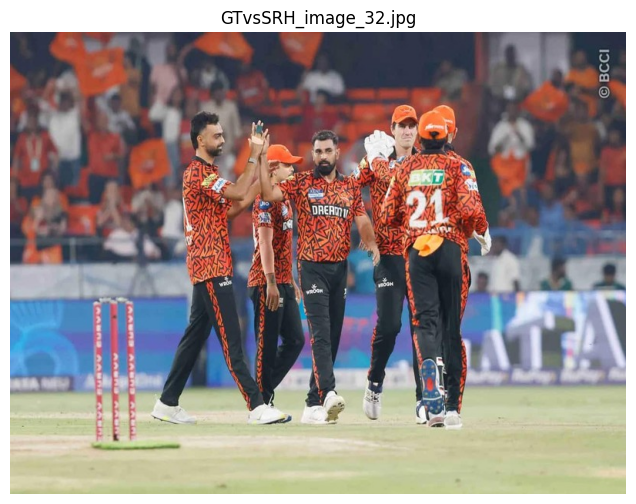

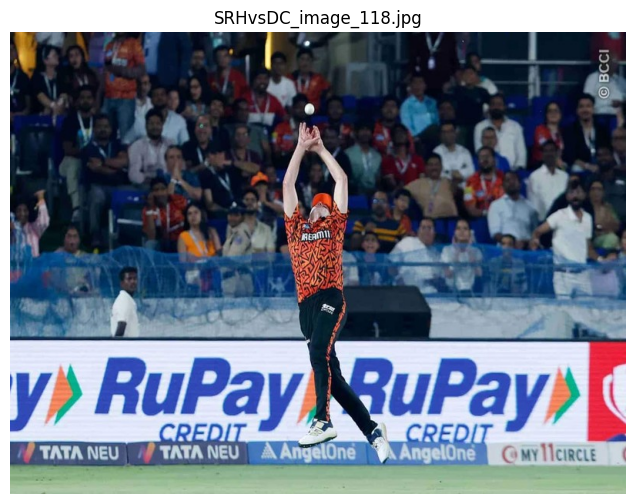

In [13]:
for path in sample_paths:

    image = load_image(path)

    plt.figure(figsize=(8,6))
    plt.imshow(image)
    plt.title(path.name)
    plt.axis("off")
    plt.show()


In [14]:
def plot_rgb_histogram(image):

    plt.figure(figsize=(10,4))

    for i, color in enumerate(["r","g","b"]):

        hist = cv2.calcHist(
            [image],
            [i],
            None,
            [256],
            [0,256]
        )

        plt.plot(hist, color=color)

    plt.title("RGB Histogram")
    plt.show()


def plot_hsv_histogram(image):

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12,4)
    )

    titles = [
        "Hue",
        "Saturation",
        "Value"
    ]

    for i in range(3):

        hist = cv2.calcHist(
            [hsv],
            [i],
            None,
            [256],
            [0,256]
        )

        axes[i].plot(hist)
        axes[i].set_title(titles[i])

    plt.tight_layout()
    plt.show()


RRvsCSK_image_257.jpg


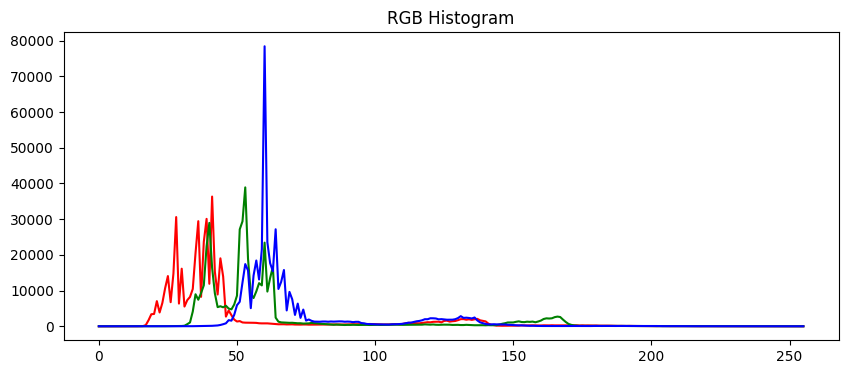

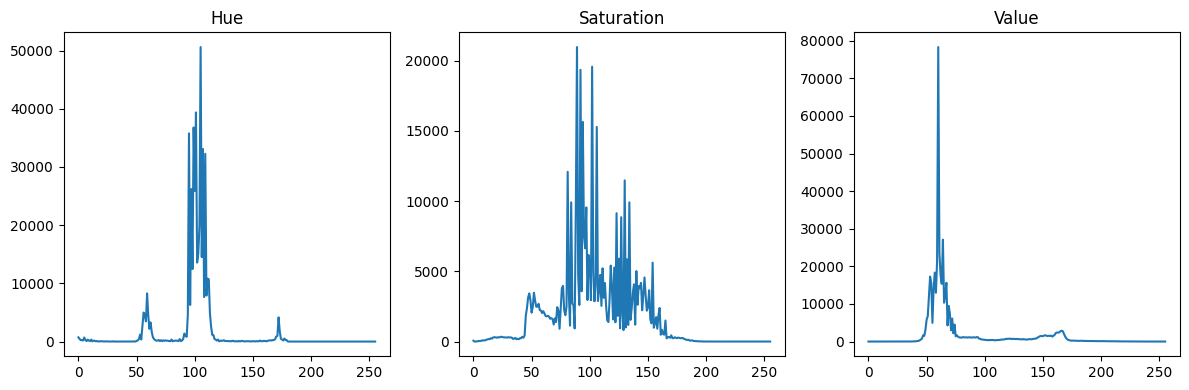

PBKSvsDC_image_70.jpg


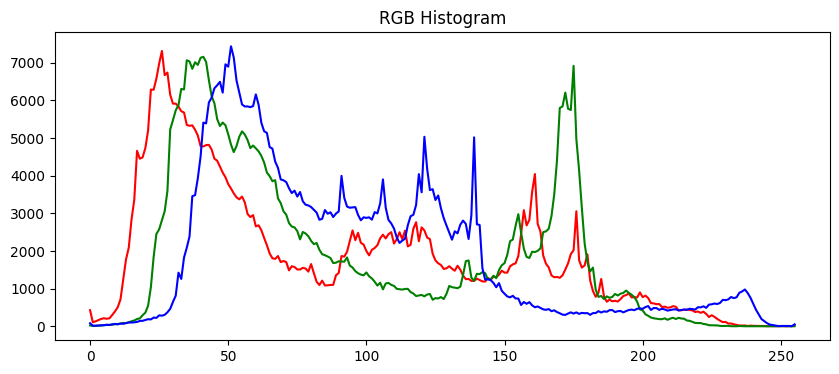

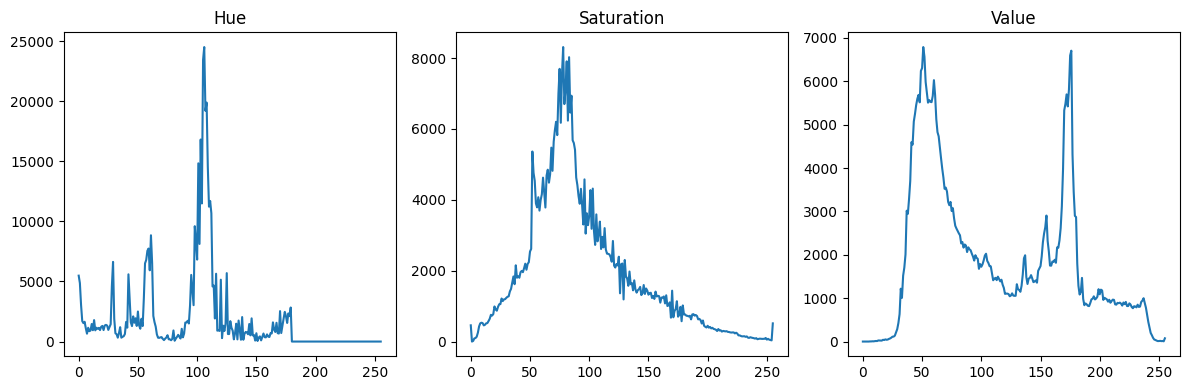

GTvsMI_image_221.jpg


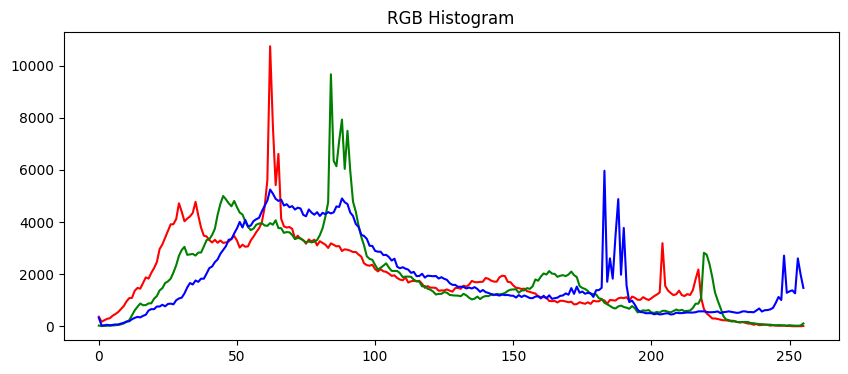

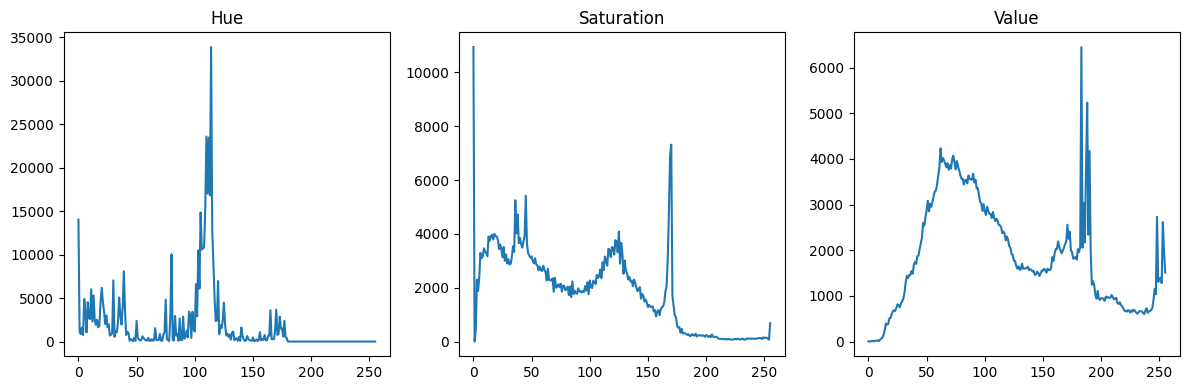

In [15]:
for path in sample_paths[:3]:

    image = load_image(path)

    print(path.name)

    plot_rgb_histogram(image)
    plot_hsv_histogram(image)


## Feature Engineering

In [16]:
# =====================================
# Grid Split
# =====================================

def split_into_cells(image):

    cells = []

    cell_width = 100
    cell_height = 75

    for row in range(8):

        for col in range(8):

            x1 = col * cell_width
            x2 = x1 + cell_width

            y1 = row * cell_height
            y2 = y1 + cell_height

            cell = image[y1:y2, x1:x2]

            cells.append(cell)

    return cells


In [17]:
# =====================================
# Feature Extractors
# =====================================

def extract_rgb_histogram(cell):

    features = []

    for channel in range(3):

        hist = cv2.calcHist(
            [cell],
            [channel],
            None,
            [16],
            [0,256]
        )

        hist = cv2.normalize(
            hist,
            hist
        ).flatten()

        features.extend(hist)

    return np.array(features)


def extract_hsv_histogram(cell):

    hsv = cv2.cvtColor(
        cell,
        cv2.COLOR_RGB2HSV
    )

    features = []

    for channel in range(3):

        hist = cv2.calcHist(
            [hsv],
            [channel],
            None,
            [16],
            [0,256]
        )

        hist = cv2.normalize(
            hist,
            hist
        ).flatten()

        features.extend(hist)

    return np.array(features)


def extract_color_moments(cell):

    features = []

    for channel in cv2.split(cell):

        features.extend([
            np.mean(channel),
            np.std(channel),
            skew(channel.flatten())
        ])

    return np.array(features)


def extract_lbp(cell):

    gray = cv2.cvtColor(
        cell,
        cv2.COLOR_RGB2GRAY
    )

    lbp = local_binary_pattern(
        gray,
        8,
        1,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0,11),
        range=(0,10)
    )

    hist = hist.astype("float")

    hist /= (
        hist.sum() + 1e-6
    )

    return hist


def extract_glcm(cell):

    gray = cv2.cvtColor(
        cell,
        cv2.COLOR_RGB2GRAY
    )

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return np.array([
        graycoprops(glcm,"contrast")[0,0],
        graycoprops(glcm,"homogeneity")[0,0],
        graycoprops(glcm,"energy")[0,0],
        graycoprops(glcm,"correlation")[0,0]
    ])


def extract_hog_features(cell):

    gray = cv2.cvtColor(
        cell,
        cv2.COLOR_RGB2GRAY
    )

    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=False
    )


def extract_features(cell):

    features = np.concatenate([

        extract_rgb_histogram(cell),
        extract_hsv_histogram(cell),
        extract_color_moments(cell),
        extract_lbp(cell),
        extract_glcm(cell),
        extract_hog_features(cell)

    ])

    return features


In [18]:
# =====================================
# Feature Vector Size Check
# =====================================

sample_image = load_image(sample_paths[0])

sample_cell = split_into_cells(
    sample_image
)[0]

feature_vector = extract_features(
    sample_cell
)

print(
    "Feature Length:",
    len(feature_vector)
)


Feature Length: 3287


In [19]:
# =====================================
# Build Training Dataset
# =====================================

feature_rows = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df)
):

    image_name = row["image"]

    image_path = IMAGE_DIR / image_name

    if not image_path.exists():
        continue

    image = load_image(image_path)

    cells = split_into_cells(image)

    for idx, cell in enumerate(cells):

        label = row[f"c{idx+1:02d}"]

        features = extract_features(cell)

        feature_row = {
            "image_name": image_name,
            "cell_id": idx + 1,
            "label": label
        }

        for f_idx, value in enumerate(features):

            feature_row[
                f"f_{f_idx+1}"
            ] = value

        feature_rows.append(
            feature_row
        )


  0%|          | 0/3073 [00:00<?, ?it/s]

  1%|          | 24/3073 [00:04<09:09,  5.55it/s]/var/folders/1m/r53kmn99675gj6mlypwb9w9r0000gn/T/ipykernel_1180/1835638354.py:67: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(channel.flatten())
100%|██████████| 3073/3073 [04:58<00:00, 10.28it/s] 


In [20]:
# =====================================
# Create Feature DataFrame
# =====================================

features_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature Dataset Shape:",
    features_df.shape
)

display(
    features_df.head()
)


Feature Dataset Shape: (108736, 3290)


,image_name,cell_id,label,f_1,f_2,f_3,f_4,f_5,f_6,f_7,...,f_3278,f_3279,f_3280,f_3281,f_3282,f_3283,f_3284,f_3285,f_3286,f_3287
0,GTvsLSG_image_0.jpg,1,0,0.819521,0.273765,0.267433,0.419384,0.057488,0.051157,0.010637,...,0.000000,0.253371,0.080312,0.046218,0.038778,0.057467,0.022716,0.101588,0.048187,0.177923
1,GTvsLSG_image_0.jpg,2,0,0.007270,0.100509,0.512661,0.542688,0.515190,0.195962,0.195330,...,0.322488,0.284265,0.035648,0.000000,0.000000,0.000000,0.000000,0.018844,0.322488,0.322488
2,GTvsLSG_image_0.jpg,3,0,0.000000,0.042769,0.142231,0.323585,0.794706,0.330879,0.268880,...,0.020055,0.292465,0.038748,0.005562,0.008795,0.007866,0.063571,0.254887,0.337620,0.337620
3,GTvsLSG_image_0.jpg,4,0,0.093658,0.460096,0.391803,0.332096,0.277462,0.178731,0.353169,...,0.000000,0.037615,0.032329,0.166200,0.301281,0.301281,0.026942,0.008866,0.000000,0.000000
4,GTvsLSG_image_0.jpg,5,0,0.243183,0.841610,0.473506,0.079453,0.028934,0.025030,0.022504,...,0.026881,0.277008,0.277008,0.138843,0.137554,0.170011,0.091778,0.084151,0.099526,0.088811


In [ ]:
# =====================================
# Save Feature Dataset
# =====================================

OUTPUT_CSV = (
    DATA_DIR / "features.csv"
)

features_df.to_csv(
    OUTPUT_CSV,
    index=False
)

print(
    "Saved:",
    OUTPUT_CSV
)
